# AI4I 2020 Predictive Maintenance Dataset - EDA

UCI에서 제공하는 [AI4I 2020 Predictive Maintenance Dataset](https://archive.ics.uci.edu/dataset/601/ai4i+2020+predictive+maintenance+dataset)에 대한 탐색적 데이터 분석(EDA)입니다.

- 데이터: 밀링 머신의 센서/공정 데이터 10,000건
- 목표: `Machine failure` 여부 및 5가지 세부 고장 모드(TWF, HDF, PWF, OSF, RNF) 분석


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

df = pd.read_csv("ai4i2020.csv")
df.columns = [c.strip() for c in df.columns]
df["Type"] = df["Type"].str.strip()  # 원본 값이 ' L   '처럼 앞뒤 공백을 포함하고 있어 groupby/countplot 전에 제거 필요
df.head()

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


## 1. 데이터 기본 정보

In [2]:
print("shape:", df.shape)
df.info()


shape: (10000, 14)
<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   UDI                      10000 non-null  int64  
 1   Product ID               10000 non-null  str    
 2   Type                     10000 non-null  str    
 3   Air temperature [K]      10000 non-null  float64
 4   Process temperature [K]  10000 non-null  float64
 5   Rotational speed [rpm]   10000 non-null  int64  
 6   Torque [Nm]              10000 non-null  float64
 7   Tool wear [min]          10000 non-null  int64  
 8   Machine failure          10000 non-null  int64  
 9   TWF                      10000 non-null  int64  
 10  HDF                      10000 non-null  int64  
 11  PWF                      10000 non-null  int64  
 12  OSF                      10000 non-null  int64  
 13  RNF                      10000 non-null  int64  
dtypes: float64(3), 

In [3]:
print("결측치 개수")
print(df.isnull().sum())
print()
print("중복 행 개수:", df.duplicated().sum())


결측치 개수
UDI                        0
Product ID                 0
Type                       0
Air temperature [K]        0
Process temperature [K]    0
Rotational speed [rpm]     0
Torque [Nm]                0
Tool wear [min]            0
Machine failure            0
TWF                        0
HDF                        0
PWF                        0
OSF                        0
RNF                        0
dtype: int64

중복 행 개수: 0


데이터는 10,000행 x 14열이며 **결측치와 중복행이 없는 깨끗한 데이터셋**입니다.

컬럼 구성:
- `UDI`, `Product ID`: 식별자
- `Type`: 제품 품질 등급 (L/M/H)
- `Air temperature [K]`, `Process temperature [K]`: 온도
- `Rotational speed [rpm]`, `Torque [Nm]`, `Tool wear [min]`: 공정 변수
- `Machine failure`: 고장 여부 (타겟)
- `TWF`, `HDF`, `PWF`, `OSF`, `RNF`: 세부 고장 모드 플래그 (공구마모, 방열, 전력, 과부하, 랜덤)


## 2. 수치형 변수 기술통계

In [4]:
num_cols = ["Air temperature [K]", "Process temperature [K]", "Rotational speed [rpm]",
            "Torque [Nm]", "Tool wear [min]"]
df[num_cols].describe().T


,count,mean,std,min,25%,50%,75%,max
Air temperature [K],10000.0,300.00493,2.000259,295.3,298.3,300.1,301.5,304.5
Process temperature [K],10000.0,310.00556,1.483734,305.7,308.8,310.1,311.1,313.8
Rotational speed [rpm],10000.0,1538.77610,179.284096,1168.0,1423.0,1503.0,1612.0,2886.0
Torque [Nm],10000.0,39.98691,9.968934,3.8,33.2,40.1,46.8,76.6
Tool wear [min],10000.0,107.95100,63.654147,0.0,53.0,108.0,162.0,253.0


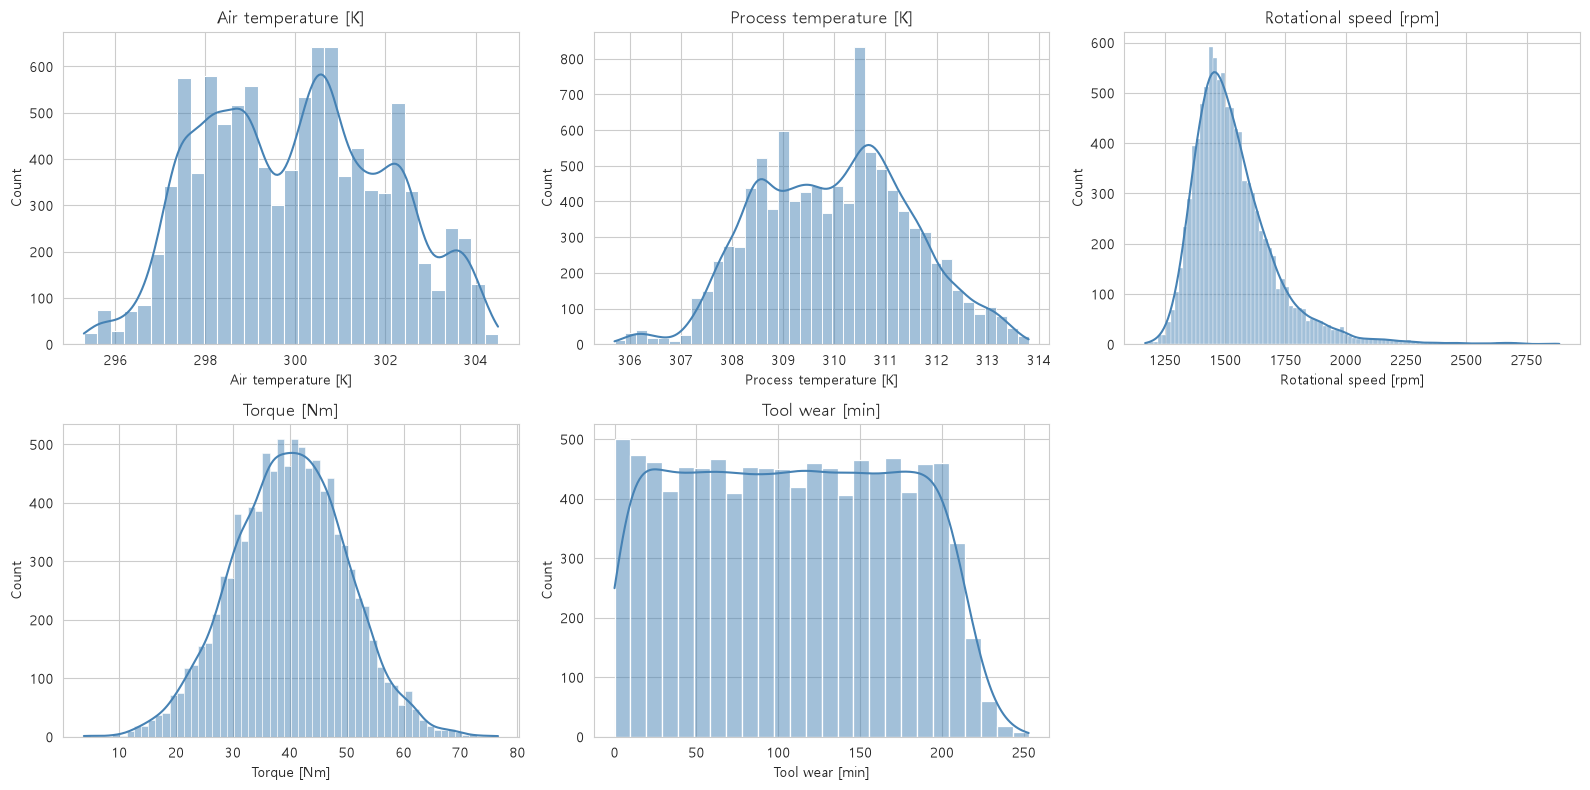

In [5]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
for ax, col in zip(axes.flatten(), num_cols):
    sns.histplot(df[col], kde=True, ax=ax, color="steelblue")
    ax.set_title(col)
axes.flatten()[-1].axis("off")
plt.tight_layout()
plt.savefig("../images/eda_histograms.png", dpi=100)
plt.show()


- `Air temperature`와 `Process temperature`는 거의 정규분포에 가깝고 서로 강한 양의 상관을 보입니다.
- `Rotational speed`는 오른쪽 꼬리가 긴(right-skewed) 분포입니다.
- `Torque`는 대체로 정규분포에 가깝습니다.
- `Tool wear`는 0~253분 사이에서 비교적 고르게 분포합니다(신품 공구가 계속 투입되는 구조로 추정).


## 3. 범주형 변수: Type

Type
L    6000
M    2997
H    1003
Name: count, dtype: int64


C:\Users\한국전파진흥협회\AppData\Local\Temp\ipykernel_19280\1929614696.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x="Type", order=["L", "M", "H"], palette="viridis")


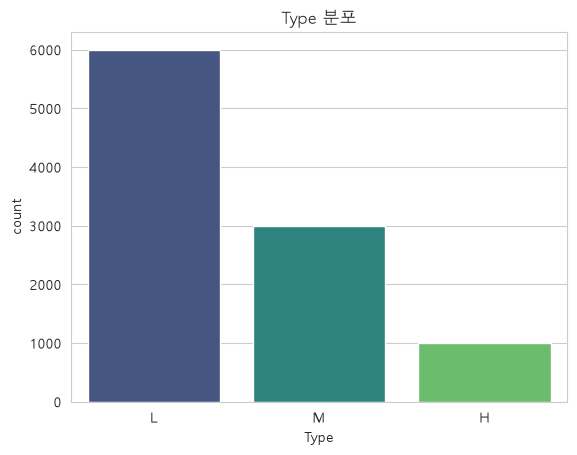

In [6]:
print(df["Type"].value_counts())
sns.countplot(data=df, x="Type", order=["L", "M", "H"], palette="viridis")
plt.title("Type 분포")
plt.savefig("../images/eda_type_dist.png", dpi=100)
plt.show()


`Type`은 제품 품질 등급으로 L(저가, 60%) > M(중가, 30%) > H(고가, 10%) 순으로 구성되어 있습니다.

## 4. 타겟 변수: Machine failure

Machine failure
0    9661
1     339
Name: count, dtype: int64
Machine failure
0    0.9661
1    0.0339
Name: proportion, dtype: float64


C:\Users\한국전파진흥협회\AppData\Local\Temp\ipykernel_19280\1472736010.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x="Machine failure", palette="Set2")


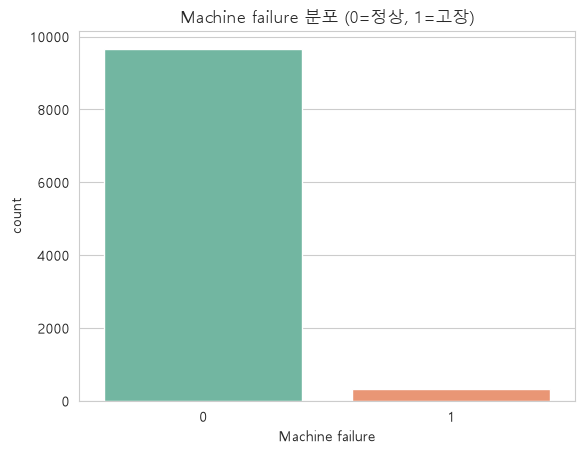

In [7]:
print(df["Machine failure"].value_counts())
print(df["Machine failure"].value_counts(normalize=True).round(4))

sns.countplot(data=df, x="Machine failure", palette="Set2")
plt.title("Machine failure 분포 (0=정상, 1=고장)")
plt.savefig("../images/eda_failure_dist.png", dpi=100)
plt.show()


전체 10,000건 중 고장(`Machine failure=1`)은 **339건(3.39%)** 으로 **극심한 클래스 불균형** 데이터입니다.
모델링 시 정확도(accuracy) 대신 recall/precision/F1, ROC-AUC 등을 사용하고, 오버/언더샘플링이나 class_weight 조정이 필요합니다.


## 5. 세부 고장 모드 분석 (TWF, HDF, PWF, OSF, RNF)

HDF    115
OSF     98
PWF     95
TWF     46
RNF     19
dtype: int64


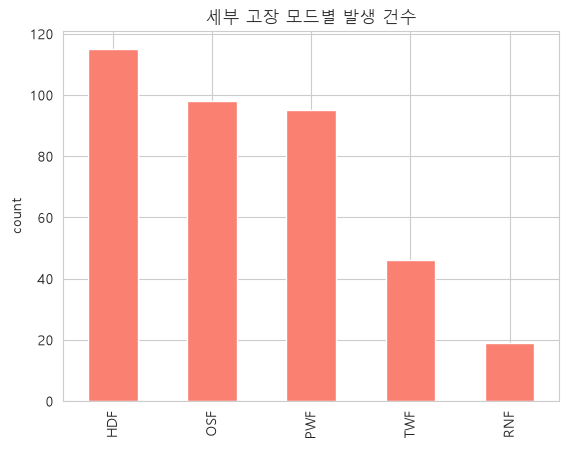

In [8]:
fail_cols = ["TWF", "HDF", "PWF", "OSF", "RNF"]
fail_counts = df[fail_cols].sum().sort_values(ascending=False)
print(fail_counts)

fail_counts.plot(kind="bar", color="salmon")
plt.title("세부 고장 모드별 발생 건수")
plt.ylabel("count")
plt.savefig("../images/eda_failure_modes.png", dpi=100)
plt.show()


In [9]:
mode_sum = df[fail_cols].sum(axis=1)
print("한 행에서 동시에 발생한 고장 모드 개수 분포:")
print(mode_sum.value_counts().sort_index())

no_mode_but_failed = df[(df["Machine failure"] == 1) & (mode_sum == 0)]
mode_but_no_failure = df[(df["Machine failure"] == 0) & (mode_sum > 0)]
print()
print("Machine failure=1 인데 세부 모드가 하나도 없는 행:", len(no_mode_but_failed))
print("Machine failure=0 인데 세부 모드가 있는 행:", len(mode_but_no_failure))


한 행에서 동시에 발생한 고장 모드 개수 분포:
0    9652
1     324
2      23
3       1
Name: count, dtype: int64

Machine failure=1 인데 세부 모드가 하나도 없는 행: 9
Machine failure=0 인데 세부 모드가 있는 행: 18


- 발생 빈도: HDF(방열 실패) > OSF(과부하) > PWF(전력) > TWF(공구마모) > RNF(랜덤) 순.
- 대부분의 고장은 세부 모드가 1개만 발생하지만, 2~3개가 동시에 발생하는 경우도 존재합니다.
- **데이터 불일치 발견**: `Machine failure=1`인데 5개 세부 모드가 모두 0인 행이 9건, 반대로 `Machine failure=0`인데 세부 모드 플래그가 켜져 있는 행이 18건 있습니다. RNF(무작위 고장)처럼 세부 모드와 최종 라벨링 규칙이 100% 일치하지 않는 원 데이터셋의 특성으로, 전처리 시 유의가 필요합니다.


## 6. 수치형 변수 간 상관관계

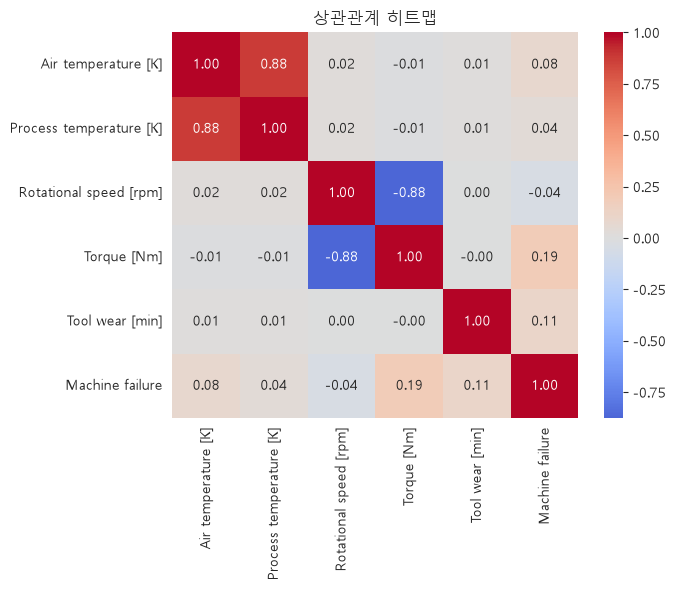

In [10]:
corr = df[num_cols + ["Machine failure"]].corr()
plt.figure(figsize=(7, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("상관관계 히트맵")
plt.tight_layout()
plt.savefig("../images/eda_corr_heatmap.png", dpi=100)
plt.show()


- `Air temperature`와 `Process temperature`: **0.88** (강한 양의 상관, 물리적으로 당연한 관계)
- `Rotational speed`와 `Torque`: **-0.88** (강한 음의 상관, 회전속도가 빠를수록 토크가 낮음 - 일정 출력 가정)
- `Machine failure`와 가장 상관이 높은 변수는 `Torque`(0.19), `Tool wear`(0.11), `Air temperature`(0.08) 순


## 7. 고장 여부에 따른 변수 분포 비교

C:\Users\한국전파진흥협회\AppData\Local\Temp\ipykernel_19280\729112256.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="Machine failure", y=col, ax=ax, palette="Set2")


C:\Users\한국전파진흥협회\AppData\Local\Temp\ipykernel_19280\729112256.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="Machine failure", y=col, ax=ax, palette="Set2")
C:\Users\한국전파진흥협회\AppData\Local\Temp\ipykernel_19280\729112256.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="Machine failure", y=col, ax=ax, palette="Set2")


C:\Users\한국전파진흥협회\AppData\Local\Temp\ipykernel_19280\729112256.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="Machine failure", y=col, ax=ax, palette="Set2")
C:\Users\한국전파진흥협회\AppData\Local\Temp\ipykernel_19280\729112256.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="Machine failure", y=col, ax=ax, palette="Set2")


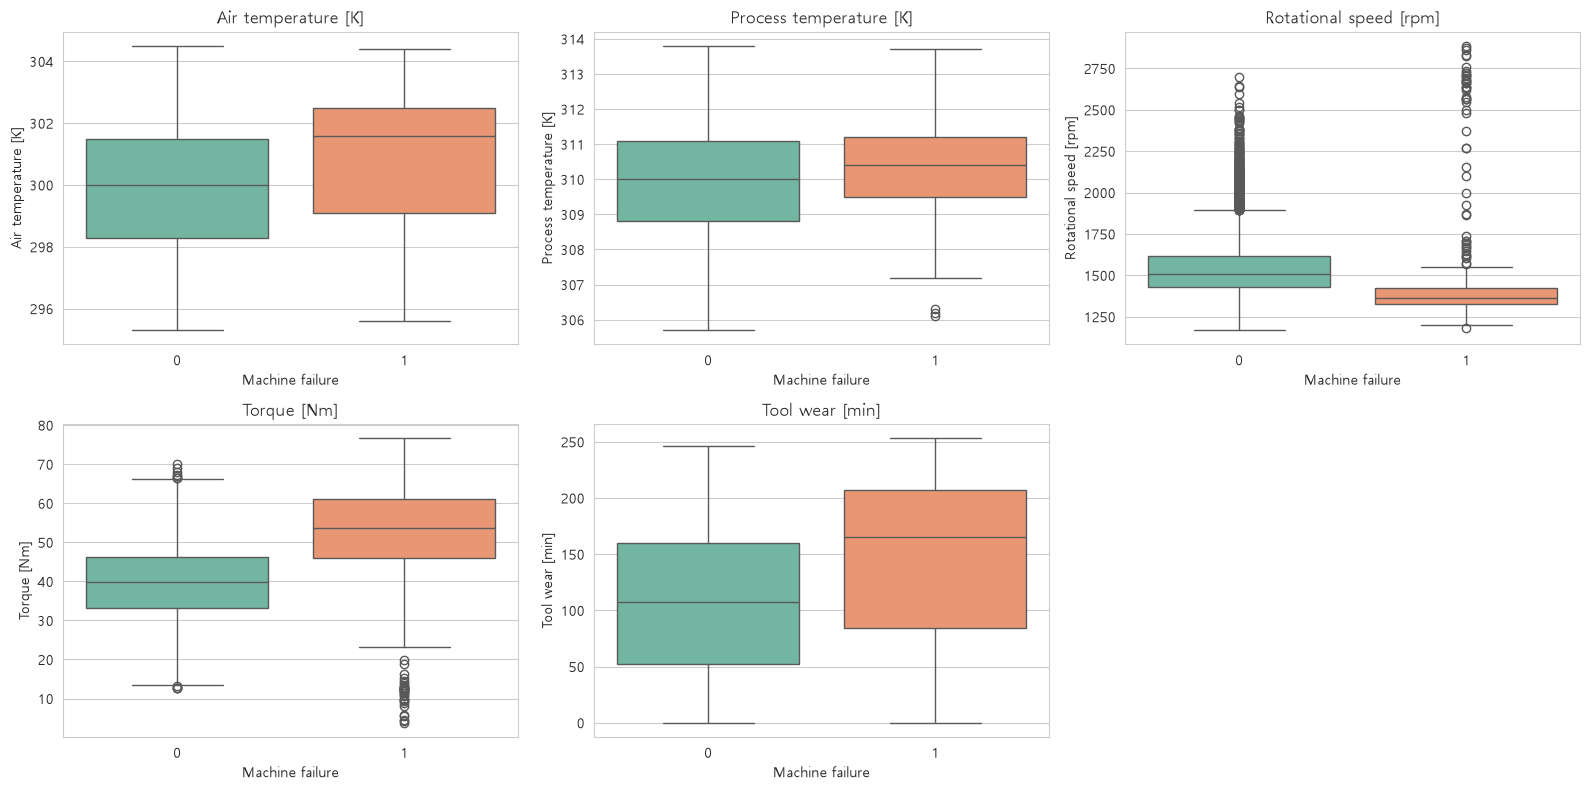

In [11]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
for ax, col in zip(axes.flatten(), num_cols):
    sns.boxplot(data=df, x="Machine failure", y=col, ax=ax, palette="Set2")
    ax.set_title(col)
axes.flatten()[-1].axis("off")
plt.tight_layout()
plt.savefig("../images/eda_boxplot_by_failure.png", dpi=100)
plt.show()


고장이 발생한 경우 `Torque`와 `Tool wear`가 대체로 더 높게 분포하며, `Rotational speed`는 고장 시 더 낮은 경향을 보입니다 (토크-회전속도의 역상관과 일치).

## 8. Type(품질 등급)별 고장률

       총건수  고장건수       고장률
Type                      
H     1003    21  0.020937
L     6000   235  0.039167
M     2997    83  0.027694


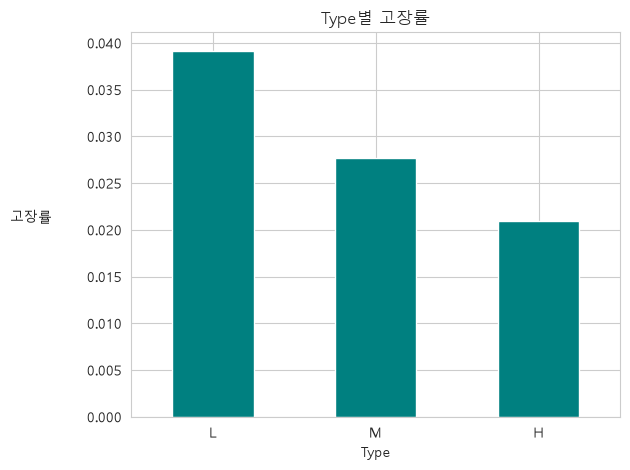

In [12]:
type_fail = df.groupby("Type")["Machine failure"].agg(["count", "sum", "mean"]).rename(
    columns={"count": "총건수", "sum": "고장건수", "mean": "고장률"})
print(type_fail)

# rot=0: pandas 기본 90도 회전 + Malgun Gothic 폰트 조합에서 x축 라벨(L/M/H)이
# 깨진 글자로 렌더링되는 버그가 있어 회전을 꺼서 우회한다.
type_fail["고장률"].reindex(["L", "M", "H"]).plot(kind="bar", color="teal", rot=0)
# rotation=0: y축 라벨(세로 회전된 한글 "고장률")도 같은 폰트+회전 조합에서
# 글자가 깨져 보이는 버그가 있어 마찬가지로 회전을 꺼서 우회한다.
plt.ylabel("고장률", rotation=0, labelpad=25, ha="right")
plt.title("Type별 고장률")
plt.tight_layout()
plt.savefig("../images/eda_failrate_by_type.png", dpi=100, bbox_inches="tight")
plt.show()

품질 등급이 낮을수록(L) 고장률이 높고(3.92%), 등급이 높을수록(H) 고장률이 낮습니다(2.09%). M은 중간(2.77%)입니다.
저가형 제품이 더 낮은 내구성/공차를 가지고 있어 고장에 더 취약한 것으로 해석됩니다.


## 9. 결론 요약

1. **결측치/중복 없음** - 전처리 부담이 적은 깨끗한 데이터셋.
2. **극심한 클래스 불균형** (정상 96.6% vs 고장 3.4%) - 모델링 시 리샘플링/가중치 조정 및 recall 중심 평가지표 필요.
3. **강한 다중공선성**: `Air temp`~`Process temp`(0.88), `Rotational speed`~`Torque`(-0.88) - 회귀/선형모델 사용 시 변수 선택 또는 차원축소 고려.
4. **고장과 가장 관련 높은 변수**: `Torque`, `Tool wear`, `Air temperature`.
5. **세부 고장 모드**: HDF(방열) > OSF(과부하) > PWF(전력) > TWF(공구마모) > RNF(랜덤) 순으로 빈번하며, `Machine failure`와 세부 모드 플래그 간 약간의 라벨 불일치 존재.
6. **품질 등급(Type)과 고장률의 관계**: L(저가) > M(중가) > H(고가) 순으로 고장률이 높음 - 등급이 낮을수록 고장에 취약.
